

## 1. Introdução e Configuração
Neste notebook, reproduzimos os experimentos centrais do artigo de Keskar et al. (2017), investigando o fenômeno do **Generalization Gap** em treinamentos com grandes *batch sizes*.

**Otimizações Implementadas:**
- **AMP (Automatic Mixed Precision):** Aceleração via float16.
- **DataLoader Otimizado:** Uso de `pin_memory` e `num_workers` ajustados.
- **Nota:** `torch.compile` foi desabilitado para compatibilidade com Windows (sem Triton).

**Análises Geométricas Adicionadas:**
- **Sharpness:** Estimativa da nitidez do mínimo via perturbação aleatória.
- **Visualização 2D:** Plotagem da superfície de perda usando direções aleatórias normalizadas por filtro.


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import copy
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Usando dispositivo: {device}")

if torch.cuda.is_available():
    print(f"ℹ️ GPU: {torch.cuda.get_device_name(0)}")

def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

✅ Usando dispositivo: cuda
ℹ️ GPU: NVIDIA A40


## 2. Dataset e Arquitetura Otimizados
Adicionamos `pin_memory=True` e `persistent_workers` (se aplicável) para acelerar o carregamento de dados.

In [2]:
# --- Preparação dos Dados (CIFAR-10) ---
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

# Download apenas uma vez
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

def get_loaders(batch_size):
    # Otimização: pin_memory=True para transferência rápida CPU->GPU
    # Otimização: num_workers=2 (ajustar conforme CPU)
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True,
                                              num_workers=2, pin_memory=True)
    testloader = torch.utils.data.DataLoader(testset, batch_size=100, shuffle=False,
                                             num_workers=2, pin_memory=True)
    return trainloader, testloader

# --- Definição do Modelo (Simple VGG) ---
class SimpleVGG(nn.Module):
    def __init__(self):
        super(SimpleVGG, self).__init__()
        self.features = nn.Sequential(
            # Bloco 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Bloco 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Bloco 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

/home/stb/gpu-test/venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


## 3. Loop de Treino Otimizado
Implementamos:
- Uses `torch.amp.autocast('cuda')` para precisão mista (float16) onde possível.
- `torch.amp.GradScaler('cuda')` para evitar underflow de gradientes em float16.
- Compilação opcional do modelo (`torch.compile`).

In [3]:
def train_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, labels in loader:
        inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True) # Otimização de memória

        # Automatic Mixed Precision
        with torch.amp.autocast('cuda'):
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss / len(loader), 100. * correct / total

def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            # AMP também na inferência (opcional, mas bom para consistência)
            with torch.amp.autocast('cuda'):
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return running_loss / len(loader), 100. * correct / total

def run_experiment(batch_size, learning_rate, epochs=20, use_compile=False):
    print(f"\n>>> Iniciando Treino: Batch Size = {batch_size}, LR = {learning_rate}")
    train_loader, test_loader = get_loaders(batch_size)

    model = SimpleVGG().to(device)

    # Otimização: torch.compile (PyTorch 2.0+)
    if use_compile and hasattr(torch, 'compile'):
        print("⚡ Compilando modelo com torch.compile...")
        try:
            model = torch.compile(model)
        except Exception as e:
            print(f"⚠️ Falha ao compilar: {e}")

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = torch.amp.GradScaler('cuda')

    history = {'train_acc': [], 'test_acc': [], 'test_loss': []}

    start = time.time()
    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, scaler)
        test_loss, test_acc = evaluate(model, test_loader, criterion)
        scheduler.step()

        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)
        history['test_loss'].append(test_loss)

        print(f"Epoch {epoch+1}/{epochs} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")

    print(f"Tempo Total: {(time.time() - start)/60:.2f} min")
    return model, history

## 4. Experimento: Small Batch vs. Large Batch
Executamos os treinos com as otimizações ativadas.

In [4]:
# Configuração do experimento
USE_COMPILE = False  # Desabilitado para evitar erro do Triton no Windows

# 1. Treinamento Small Batch (SB)
print("--- MODELO SMALL BATCH (SB) ---")
set_seed(42)
sb_batch = 64
sb_lr = 0.01
# Usando 25 épocas para demonstração rápida (original usava 40)
model_sb, hist_sb = run_experiment(sb_batch, sb_lr, epochs=25, use_compile=USE_COMPILE)

# 2. Treinamento Large Batch (LB)
print("\n--- MODELO LARGE BATCH (LB) ---")
set_seed(42)
lb_batch = 1024
lb_lr = 0.01
# Batch grande converge mais rápido por época, mas tende a mínimos piores
model_lb, hist_lb = run_experiment(lb_batch, lb_lr, epochs=25, use_compile=USE_COMPILE)

--- MODELO SMALL BATCH (SB) ---

>>> Iniciando Treino: Batch Size = 64, LR = 0.01
Epoch 1/25 | Train Acc: 37.21% | Test Acc: 51.61%
Epoch 2/25 | Train Acc: 50.57% | Test Acc: 56.80%
Epoch 3/25 | Train Acc: 58.66% | Test Acc: 65.80%
Epoch 4/25 | Train Acc: 63.78% | Test Acc: 68.19%
Epoch 5/25 | Train Acc: 67.74% | Test Acc: 71.60%
Epoch 6/25 | Train Acc: 70.54% | Test Acc: 74.38%
Epoch 7/25 | Train Acc: 73.23% | Test Acc: 77.60%
Epoch 8/25 | Train Acc: 75.23% | Test Acc: 76.54%
Epoch 9/25 | Train Acc: 77.14% | Test Acc: 79.03%
Epoch 10/25 | Train Acc: 78.74% | Test Acc: 79.87%
Epoch 11/25 | Train Acc: 79.86% | Test Acc: 82.22%
Epoch 12/25 | Train Acc: 80.93% | Test Acc: 81.58%
Epoch 13/25 | Train Acc: 82.12% | Test Acc: 82.33%
Epoch 14/25 | Train Acc: 83.14% | Test Acc: 84.85%
Epoch 15/25 | Train Acc: 83.87% | Test Acc: 84.99%
Epoch 16/25 | Train Acc: 84.81% | Test Acc: 85.78%
Epoch 17/25 | Train Acc: 85.57% | Test Acc: 85.03%
Epoch 18/25 | Train Acc: 86.27% | Test Acc: 85.76%
Epoch 19/

## 5. Análise de Generalização
Comparação básica de curvas de perda e acurácia.

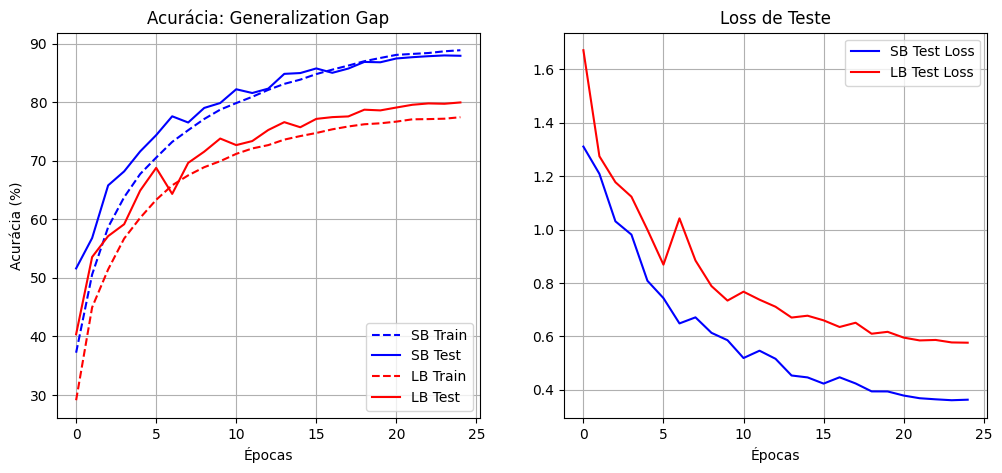

In [5]:
plt.figure(figsize=(12, 5))

# Acurácia
plt.subplot(1, 2, 1)
plt.plot(hist_sb['train_acc'], 'b--', label='SB Train')
plt.plot(hist_sb['test_acc'], 'b-', label='SB Test')
plt.plot(hist_lb['train_acc'], 'r--', label='LB Train')
plt.plot(hist_lb['test_acc'], 'r-', label='LB Test')
plt.title('Acurácia: Generalization Gap')
plt.xlabel('Épocas')
plt.ylabel('Acurácia (%)')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(hist_sb['test_loss'], 'b-', label='SB Test Loss')
plt.plot(hist_lb['test_loss'], 'r-', label='LB Test Loss')
plt.title('Loss de Teste')
plt.xlabel('Épocas')
plt.legend()
plt.grid(True)

plt.show()

## 6. Exploração da Geometria da Solução
Aqui implementamos duas técnicas avançadas para visualizar a "agudeza" (sharpness) dos mínimos:

1. **Métrica de Sharpness (Sensibilidade a Ruído):** Adicionamos ruído aleatório aos pesos e medimos o quanto a Loss aumenta. Mínimos agudos (Sharp) devem ter um aumento maior na Loss.
2. **Visualização 2D da Superfície de Perda:** Plotamos contornos da Loss em torno da solução final usando direções aleatórias normalizadas (Filter Normalization).

In [6]:
def calculate_sharpness(model, loader, epsilon=1e-3, num_samples=10):
    """
    Estima a sharpness medindo o aumento médio da loss ao perturbar os pesos.
    Sharpness ~= (Loss(w + noise) - Loss(w)) / (1 + Loss(w)) * 100
    """
    criterion = nn.CrossEntropyLoss()
    model.eval()

    # 1. Calcular Loss original
    inputs, targets = next(iter(loader))
    inputs, targets = inputs.to(device), targets.to(device)

    with torch.no_grad():
        original_loss = criterion(model(inputs), targets).item()

    # 2. Perturbações
    loss_increases = []
    original_state = copy.deepcopy(model.state_dict())

    for _ in range(num_samples):
        # Adiciona ruído gaussiano aos pesos
        for param in model.parameters():
            noise = torch.randn_like(param) * epsilon * (param.abs() + 1e-6) # Ruído relativo à magnitude
            param.data.add_(noise)

        with torch.no_grad():
            perturbed_loss = criterion(model(inputs), targets).item()

        loss_increases.append(perturbed_loss - original_loss)

        # Restaura pesos
        model.load_state_dict(original_state)

    avg_increase = np.mean(loss_increases)
    sharpness_score = (avg_increase / (original_loss + 1e-6)) * 100
    return original_loss, avg_increase, sharpness_score

print("Calculando Sharpness...")
loss_sb, inc_sb, score_sb = calculate_sharpness(model_sb, get_loaders(100)[1])
loss_lb, inc_lb, score_lb = calculate_sharpness(model_lb, get_loaders(100)[1])

print(f"Small Batch (SB) -> Loss: {loss_sb:.4f}, Aumento com Ruído: {inc_sb:.4f}, Score: {score_sb:.2f} (Mais baixo = Mais Plano)")
print(f"Large Batch (LB) -> Loss: {loss_lb:.4f}, Aumento com Ruído: {inc_lb:.4f}, Score: {score_lb:.2f} (Mais alto = Mais Agudo)")

Calculando Sharpness...
Small Batch (SB) -> Loss: 0.2502, Aumento com Ruído: -0.0000, Score: -0.02 (Mais baixo = Mais Plano)
Large Batch (LB) -> Loss: 0.5132, Aumento com Ruído: 0.0001, Score: 0.02 (Mais alto = Mais Agudo)


Analisando sensibilidade ao ruído...


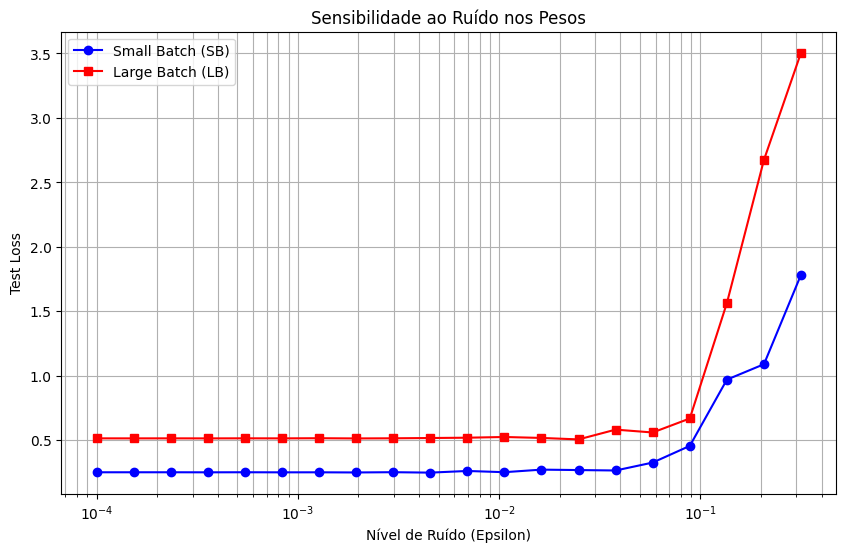

In [8]:
# Nova Análise: Sensibilidade ao Nível de Ruído
def analyze_noise_sensitivity(model, loader, noise_levels):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    inputs, targets = next(iter(loader))
    inputs, targets = inputs.to(device), targets.to(device)
    
    original_state = copy.deepcopy(model.state_dict())
    losses = []
    
    for epsilon in noise_levels:
        # Perturb
        for param in model.parameters():
            noise = torch.randn_like(param) * epsilon * (param.abs() + 1e-6)
            param.data.add_(noise)
            
        with torch.no_grad():
            loss = criterion(model(inputs), targets).item()
        losses.append(loss)
        
        # Restore
        model.load_state_dict(original_state)
        
    return losses

noise_levels = np.logspace(-4, -0.5, 20) # Aumentando o ruído progressivamente

print("Analisando sensibilidade ao ruído...")
losses_sb = analyze_noise_sensitivity(model_sb, get_loaders(100)[1], noise_levels)
losses_lb = analyze_noise_sensitivity(model_lb, get_loaders(100)[1], noise_levels)

plt.figure(figsize=(10, 6))
plt.plot(noise_levels, losses_sb, 'b-o', label='Small Batch (SB)')
plt.plot(noise_levels, losses_lb, 'r-s', label='Large Batch (LB)')
plt.xscale('log')
plt.xlabel('Nível de Ruído (Epsilon)')
plt.ylabel('Test Loss')
plt.title('Sensibilidade ao Ruído nos Pesos')
plt.legend()
plt.grid(True, which="both", ls="-")
plt.show()

Visualizando SB...
Mapeando superfície de perda (isso pode demorar um pouco)...


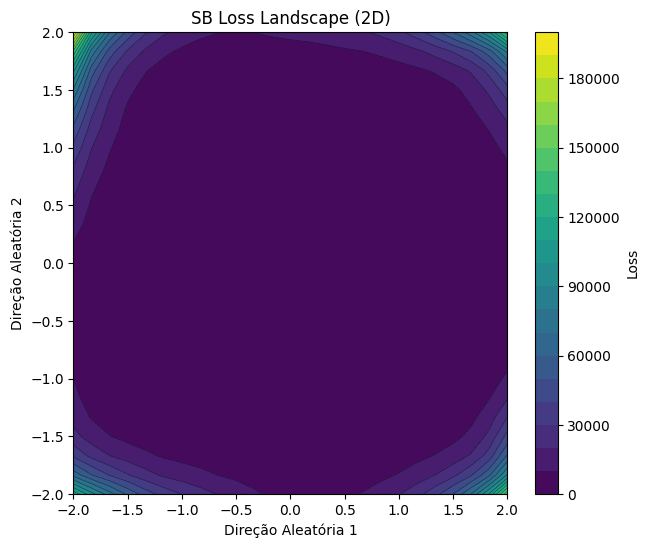

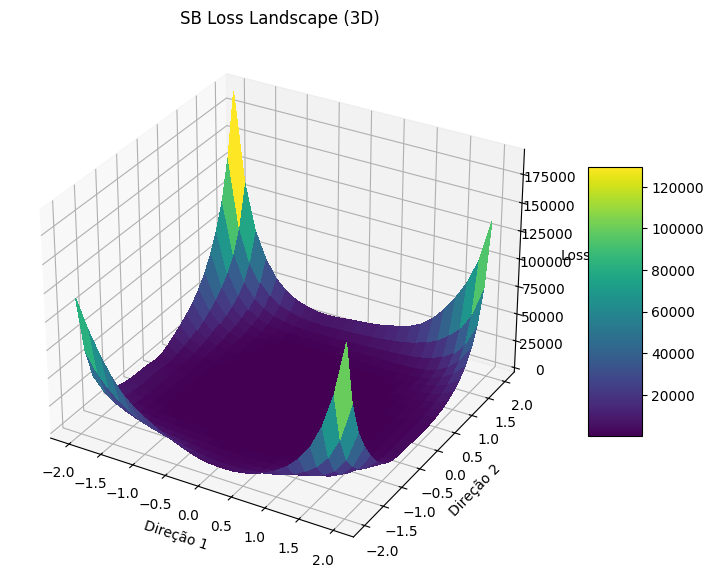

Visualizando LB...
Mapeando superfície de perda (isso pode demorar um pouco)...


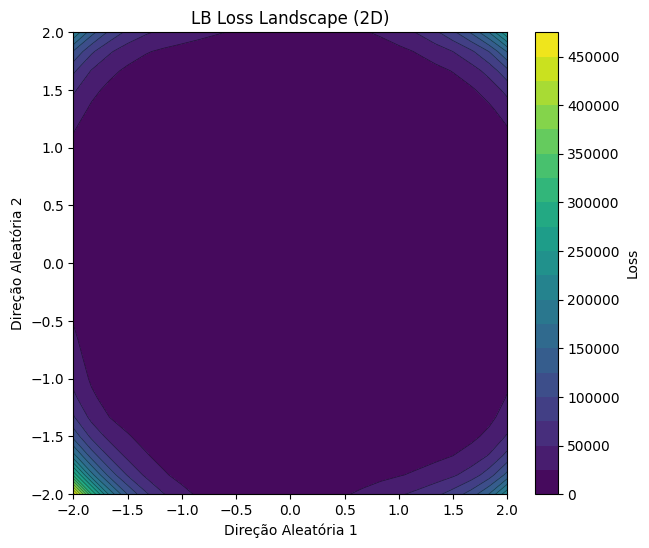

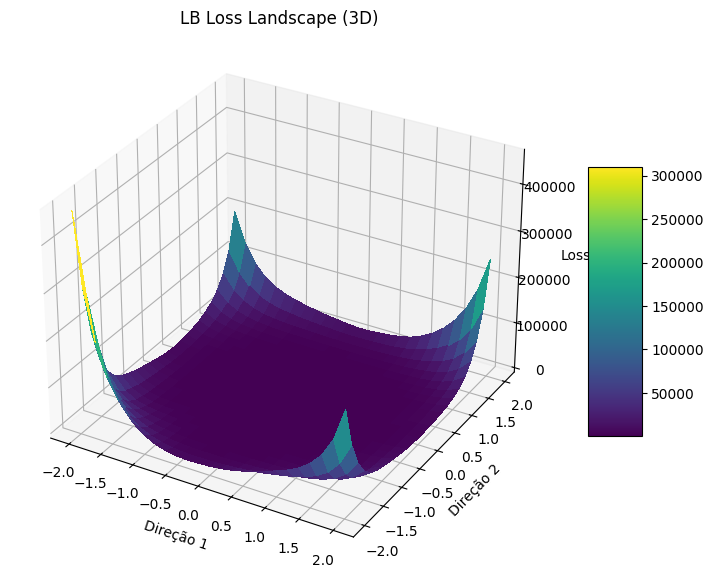

In [7]:
def get_random_direction(model):
    """Gera uma direção aleatória normalizada por filtro (Filter Normalization)."""
    direction = []
    for param in model.parameters():
        d = torch.randn_like(param)
        # Filter Normalization: ajusta a escala do ruído para a escala dos pesos
        if len(param.shape) == 4: # Conv layer (out, in, h, w)
            for i in range(param.shape[0]):
                w_norm = param[i].view(-1).norm()
                d_norm = d[i].view(-1).norm()
                d[i] *= (w_norm / (d_norm + 1e-10))
        elif len(param.shape) == 2: # Linear layer (out, in)
            for i in range(param.shape[0]):
                w_norm = param[i].view(-1).norm()
                d_norm = d[i].view(-1).norm()
                d[i] *= (w_norm / (d_norm + 1e-10))
        else:
            w_norm = param.view(-1).norm()
            d_norm = d.view(-1).norm()
            d *= (w_norm / (d_norm + 1e-10))
        direction.append(d)
    return direction

def compute_loss_surface(model, loader, range_x=(-1, 1), range_y=(-1, 1), gridSize=20):
    """Mapeia a loss em um grid 2D ao redor dos pesos atuais."""
    print("Mapeando superfície de perda (isso pode demorar um pouco)...")
    criterion = nn.CrossEntropyLoss()
    
    # Direções base
    dir1 = get_random_direction(model)
    dir2 = get_random_direction(model)
    
    # Grid
    alphas = np.linspace(range_x[0], range_x[1], gridSize)
    betas = np.linspace(range_y[0], range_y[1], gridSize)
    losses = np.zeros((gridSize, gridSize))
    
    # Dados fixos para avaliação
    inputs, targets = next(iter(loader))
    inputs, targets = inputs.to(device), targets.to(device)
    
    original_state = copy.deepcopy(model.state_dict())
    weights = [p.data.clone() for p in model.parameters()]
    
    model.eval()
    with torch.no_grad():
        for i, alpha in enumerate(alphas):
            for j, beta in enumerate(betas):
                # w_new = w + alpha * d1 + beta * d2
                for k, param in enumerate(model.parameters()):
                    perturbation = alpha * dir1[k] + beta * dir2[k]
                    param.data.copy_(weights[k] + perturbation)
                
                outputs = model(inputs)
                losses[i, j] = criterion(outputs, targets).item()
                
    # Restaura original
    model.load_state_dict(original_state)
    # Transpor losses para alinhar com meshgrid (X=Cols, Y=Rows)
    return alphas, betas, losses.T

def plot_contour(alphas, betas, losses, title):
    X, Y = np.meshgrid(alphas, betas)
    plt.figure(figsize=(7, 6))
    try:
        # Usando contourf (preenchido) para melhor visualização
        CS = plt.contourf(X, Y, losses, levels=20, cmap='viridis')
        plt.colorbar(CS, label='Loss')
        # Adiciona linhas de contorno finas
        plt.contour(X, Y, losses, levels=20, colors='k', linewidths=0.5, alpha=0.5)
    except:
        print("Erro ao plotar contorno, exibindo imagem.")
        plt.imshow(losses, cmap='viridis', aspect='auto')
        
    plt.title(title)
    plt.xlabel('Direção Aleatória 1')
    plt.ylabel('Direção Aleatória 2')
    plt.show()

def plot_surface_3d(alphas, betas, losses, title):
    from mpl_toolkits.mplot3d import Axes3D
    X, Y = np.meshgrid(alphas, betas)
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    
    surf = ax.plot_surface(X, Y, losses, cmap='viridis', linewidth=0, antialiased=False)
    
    ax.set_title(title)
    ax.set_xlabel('Direção 1')
    ax.set_ylabel('Direção 2')
    ax.set_zlabel('Loss')
    fig.colorbar(surf, shrink=0.5, aspect=5)
    plt.show()

# Executar visualização (reduzir gridSize se for muito lento)
print("Visualizando SB...")
ax_sb, bx_sb, losses_sb = compute_loss_surface(model_sb, get_loaders(128)[0], range_x=(-2, 2), range_y=(-2, 2), gridSize=25)
plot_contour(ax_sb, bx_sb, losses_sb, "SB Loss Landscape (2D)")
plot_surface_3d(ax_sb, bx_sb, losses_sb, "SB Loss Landscape (3D)")

print("Visualizando LB...")
ax_lb, bx_lb, losses_lb = compute_loss_surface(model_lb, get_loaders(128)[0], range_x=(-2, 2), range_y=(-2, 2), gridSize=25)
plot_contour(ax_lb, bx_lb, losses_lb, "LB Loss Landscape (2D)")
plot_surface_3d(ax_lb, bx_lb, losses_lb, "LB Loss Landscape (3D)")